# EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [2]:
# read file
df = pd.read_csv('masterfiles/all_users_all_metrics.csv')

In [3]:
df.drop(columns=['oxygen_saturation_average_value_previous_day', 'rmssd_previous_day', 'daily_respiratory_rate_previous_day'], inplace=True)

In [4]:
# display first few rows
df.head()

,user_id,date,overall_score_previous_day,deep_sleep_in_minutes_previous_day,overall_score,deep_sleep_in_minutes,oxygen_saturation_average_value,rmssd,daily_respiratory_rate,dq_stress level,dq_anxiety level
0,1,2025-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,0.0
1,1,2025-02-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,0.0
2,1,2025-02-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0.0
3,1,2025-02-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,8.0
4,1,2025-02-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,7.0


In [5]:
# drop rows with missing values
df_cleaned = df.dropna()
df.shape, df_cleaned.shape

((3469, 11), (1036, 11))

In [6]:
# Descriptive statistics
df_cleaned.describe()

,user_id,overall_score_previous_day,deep_sleep_in_minutes_previous_day,overall_score,deep_sleep_in_minutes,oxygen_saturation_average_value,rmssd,daily_respiratory_rate,dq_stress level,dq_anxiety level
count,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000,1036.000000
mean,19.566602,76.111004,76.986486,76.032819,77.385135,94.886583,68.111336,15.779151,34.180502,34.983591
std,10.416097,7.456426,24.181596,7.746521,24.405023,1.339061,34.940306,2.343050,23.433434,26.121765
min,1.000000,46.000000,8.000000,40.000000,8.000000,87.700000,0.000000,10.600000,0.000000,0.000000
25%,8.000000,72.000000,60.000000,71.750000,61.000000,94.100000,41.215250,14.200000,16.000000,14.000000
50%,21.000000,77.000000,76.000000,77.000000,76.500000,95.000000,62.851500,15.600000,30.000000,29.000000
75%,28.000000,81.000000,92.000000,81.000000,92.250000,95.800000,88.084500,17.200000,49.000000,51.250000
max,35.000000,94.000000,177.000000,94.000000,177.000000,99.000000,149.605000,24.400000,100.000000,100.000000


## 1. Variable Names and Data types

In [7]:
print("Columns:", list(df.columns))
print()
df.info()


Columns: ['user_id', 'date', 'overall_score_previous_day', 'deep_sleep_in_minutes_previous_day', 'overall_score', 'deep_sleep_in_minutes', 'oxygen_saturation_average_value', 'rmssd', 'daily_respiratory_rate', 'dq_stress level', 'dq_anxiety level']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3469 entries, 0 to 3468
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   user_id                             3469 non-null   int64  
 1   date                                3467 non-null   object 
 2   overall_score_previous_day          1798 non-null   float64
 3   deep_sleep_in_minutes_previous_day  1798 non-null   float64
 4   overall_score                       1466 non-null   float64
 5   deep_sleep_in_minutes               1466 non-null   float64
 6   oxygen_saturation_average_value     2027 non-null   float64
 7   rmssd                               1849 non-null   fl

In [8]:
# Convert to appropriate types
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
if "user_id" in df.columns:
    df["user_id"] = df["user_id"].astype(str)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [c for c in df.columns if c not in numeric_cols]
print("Numeric cols:", numeric_cols)
print("Non-numeric cols:", non_numeric_cols)


Numeric cols: ['overall_score_previous_day', 'deep_sleep_in_minutes_previous_day', 'overall_score', 'deep_sleep_in_minutes', 'oxygen_saturation_average_value', 'rmssd', 'daily_respiratory_rate', 'dq_stress level', 'dq_anxiety level']
Non-numeric cols: ['user_id', 'date']


## 2. Missing values percentage

In [9]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
missing_pct.to_frame("missing_%").head(30)


,missing_%
overall_score,57.74
deep_sleep_in_minutes,57.74
overall_score_previous_day,48.17
deep_sleep_in_minutes_previous_day,48.17
daily_respiratory_rate,47.59
rmssd,46.70
oxygen_saturation_average_value,41.57
dq_stress level,15.80
dq_anxiety level,15.80
date,0.06


In [10]:
# show records with empty date
if "date" in df.columns:
    print("Records with empty date:")
    print(df[df["date"].isna()])

Records with empty date:
     user_id date  overall_score_previous_day  deep_sleep_in_minutes_previous_day  overall_score  deep_sleep_in_minutes  \
1217      20  NaT                        67.0                                77.0           67.0                   77.0   
1927      27  NaT                        77.0                                46.0           77.0                   46.0   

      oxygen_saturation_average_value  rmssd  daily_respiratory_rate  dq_stress level  dq_anxiety level  
1217                              NaN    NaN                     NaN              NaN               NaN  
1927                              NaN    NaN                     NaN              NaN               NaN  


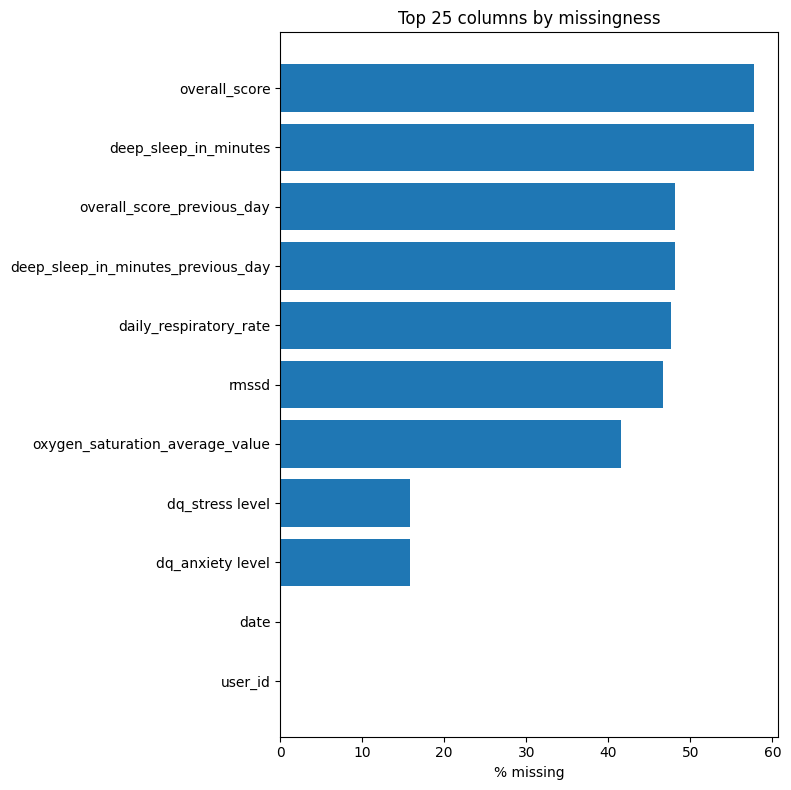

In [11]:
# Simple bar plot for top-25 missing
top_n = 25
mp = missing_pct.head(top_n).iloc[::-1]
plt.figure(figsize=(8, 8))
plt.barh(mp.index, mp.values)
plt.xlabel("% missing")
plt.title(f"Top {top_n} columns by missingness")
plt.tight_layout()
plt.show()


## 3. Checking for outliers

In [12]:
# Basic stats
desc = df[numeric_cols].describe().T
desc


,count,mean,std,min,25%,50%,75%,max
overall_score_previous_day,1798.0,75.755840,8.135395,40.0,71.000,77.000,82.00,94.000
deep_sleep_in_minutes_previous_day,1798.0,76.994994,25.194082,5.0,60.000,76.000,93.00,177.000
overall_score,1466.0,76.034789,7.875448,40.0,71.250,77.000,82.00,94.000
deep_sleep_in_minutes,1466.0,77.467940,24.523792,8.0,60.000,77.000,93.00,177.000
oxygen_saturation_average_value,2027.0,94.904193,1.334010,87.7,94.100,95.000,95.80,99.000
rmssd,1849.0,66.975899,34.376177,0.0,41.362,62.774,87.16,149.605
daily_respiratory_rate,1818.0,15.822332,2.332061,10.6,14.200,15.600,17.20,24.400
dq_stress level,2921.0,33.542280,25.713550,0.0,13.000,27.000,49.00,100.000
dq_anxiety level,2921.0,34.727833,27.267426,0.0,12.000,28.000,52.00,100.000


In [13]:
df['overall_score'].unique()

array([nan, 85., 82., 84., 81., 80., 83., 75., 74., 90., 88., 92., 87.,
       77., 71., 79., 89., 78., 73., 72., 69., 64., 70., 67., 76., 68.,
       59., 63., 62., 60., 65., 58., 45., 66., 86., 55., 49., 57., 51.,
       54., 40., 61., 50., 56., 44., 53., 46., 91., 93., 94.])

In [14]:
# Outlier counts per numeric col using IQR rule
outlier_counts = {}
for c in numeric_cols:
    s = df[c].dropna()
    if s.empty:
        outlier_counts[c] = 0
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_counts[c] = ((s < low) | (s > high)).sum()
pd.Series(outlier_counts).sort_values(ascending=False)


oxygen_saturation_average_value       43
daily_respiratory_rate                29
overall_score_previous_day            26
overall_score                         20
deep_sleep_in_minutes_previous_day    15
deep_sleep_in_minutes                 11
rmssd                                  0
dq_stress level                        0
dq_anxiety level                       0
dtype: int64

## 4. Distributions

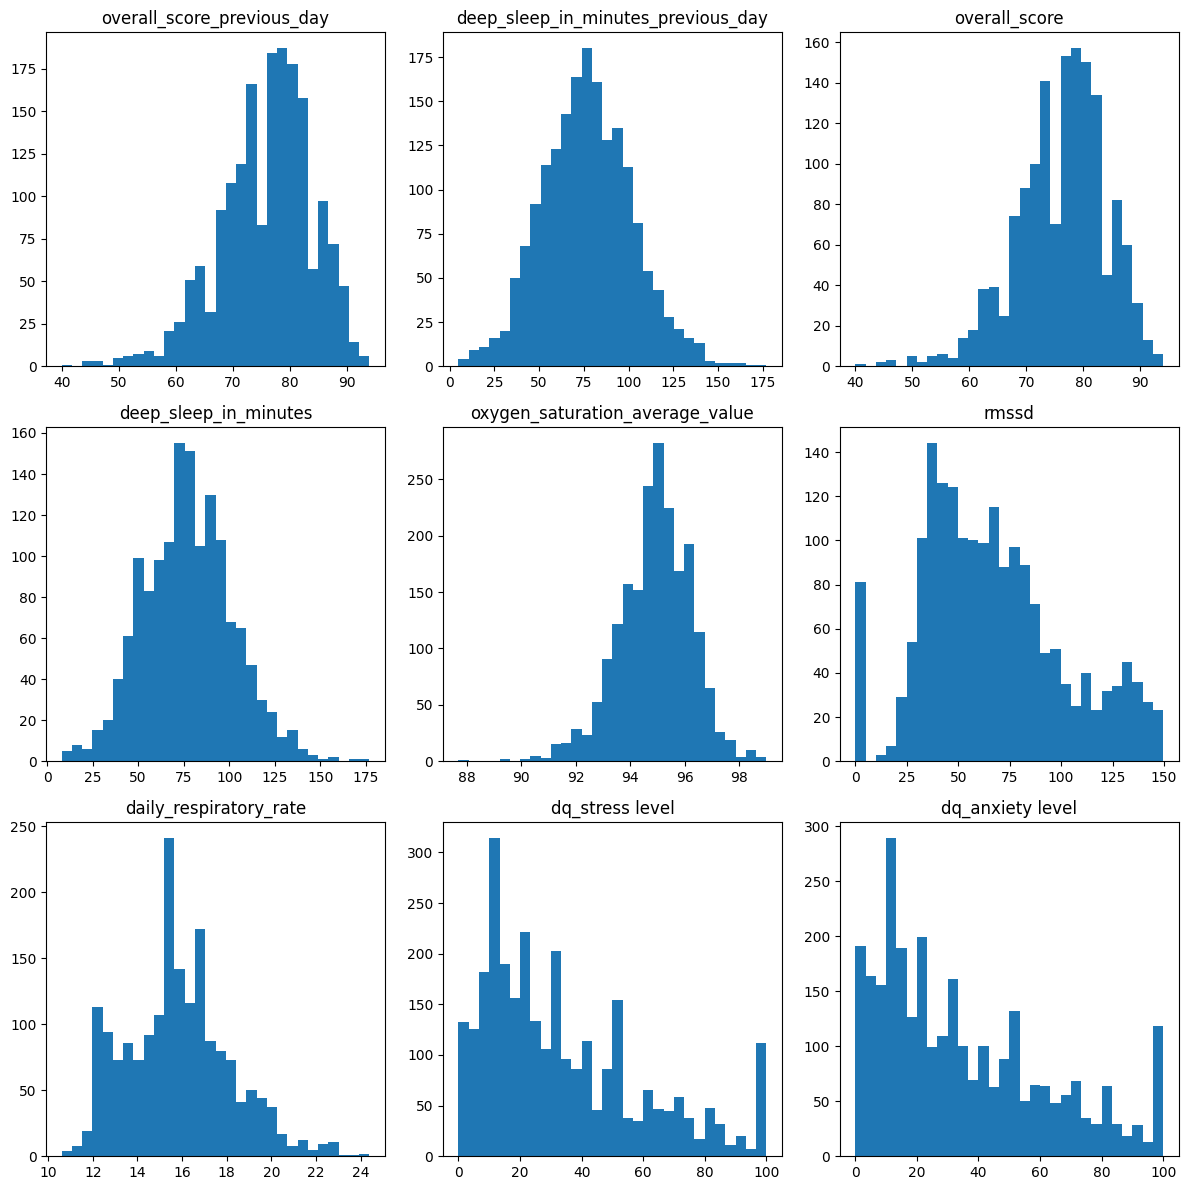

In [15]:
# Histograms for numeric columns
cols = numeric_cols[:]
per_page = 9

for start in range(0, len(cols), per_page):
    subset = cols[start:start+per_page]
    n = len(subset)
    rows = int(np.ceil(n/3))
    fig, axes = plt.subplots(rows, 3, figsize=(12, 4*rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, subset):
        ax.hist(df[c].dropna(), bins=30)
        ax.set_title(c)
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()



Rangos: 2025-01-30 → 2025-06-19  (10 quincenas)


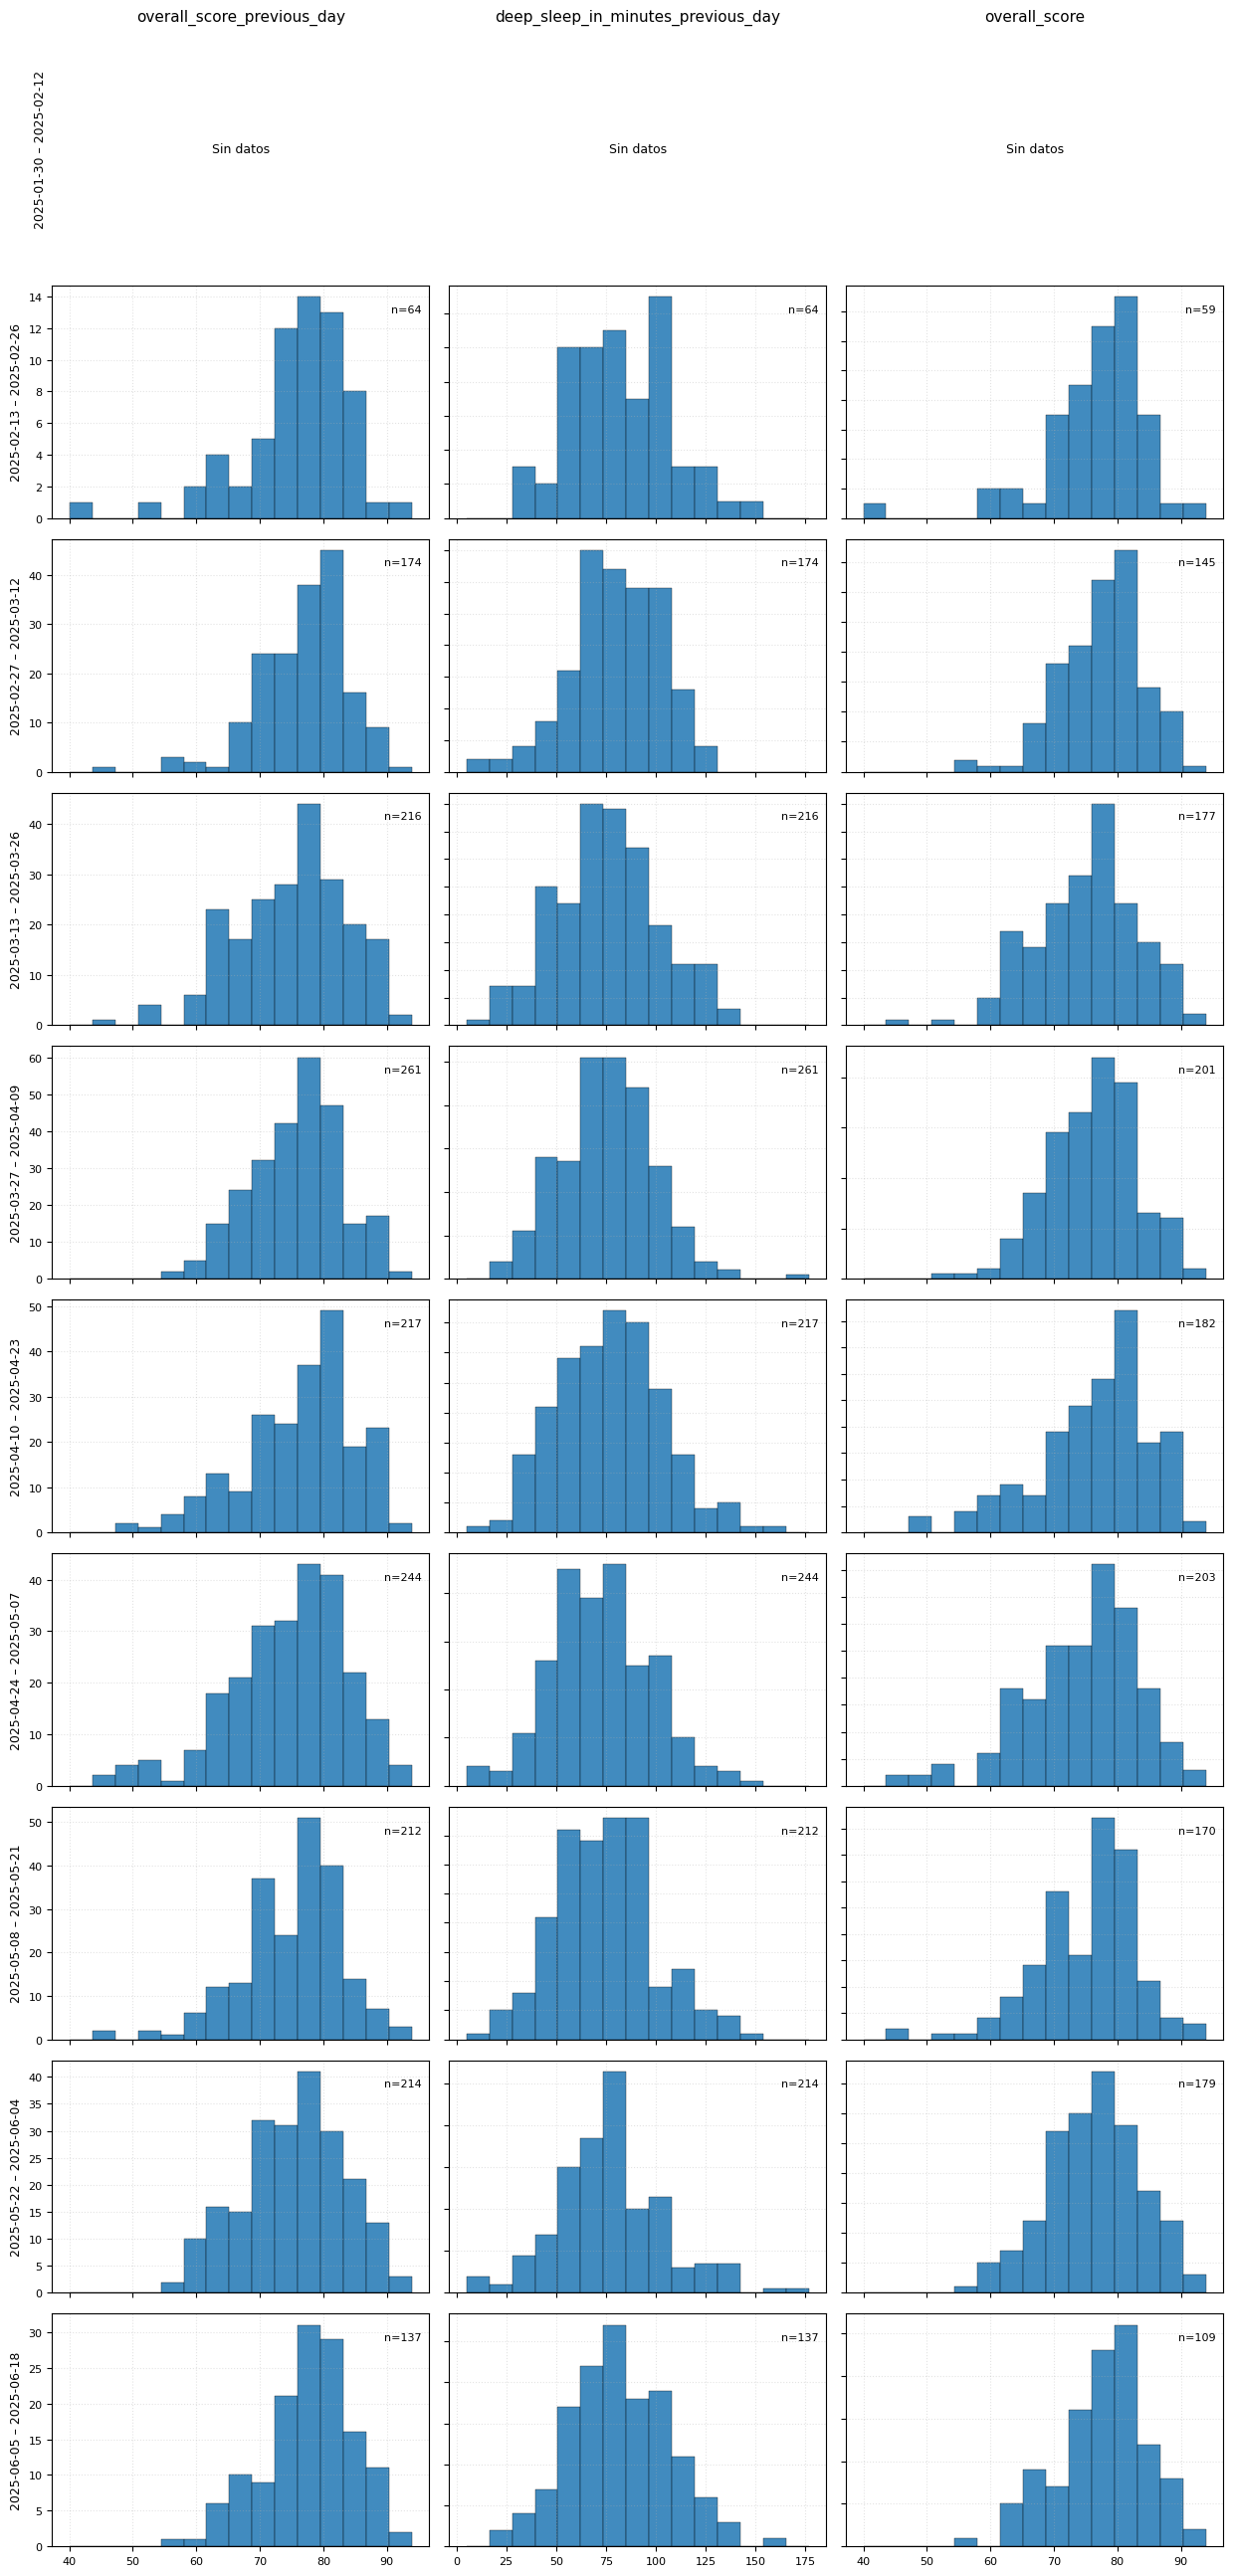

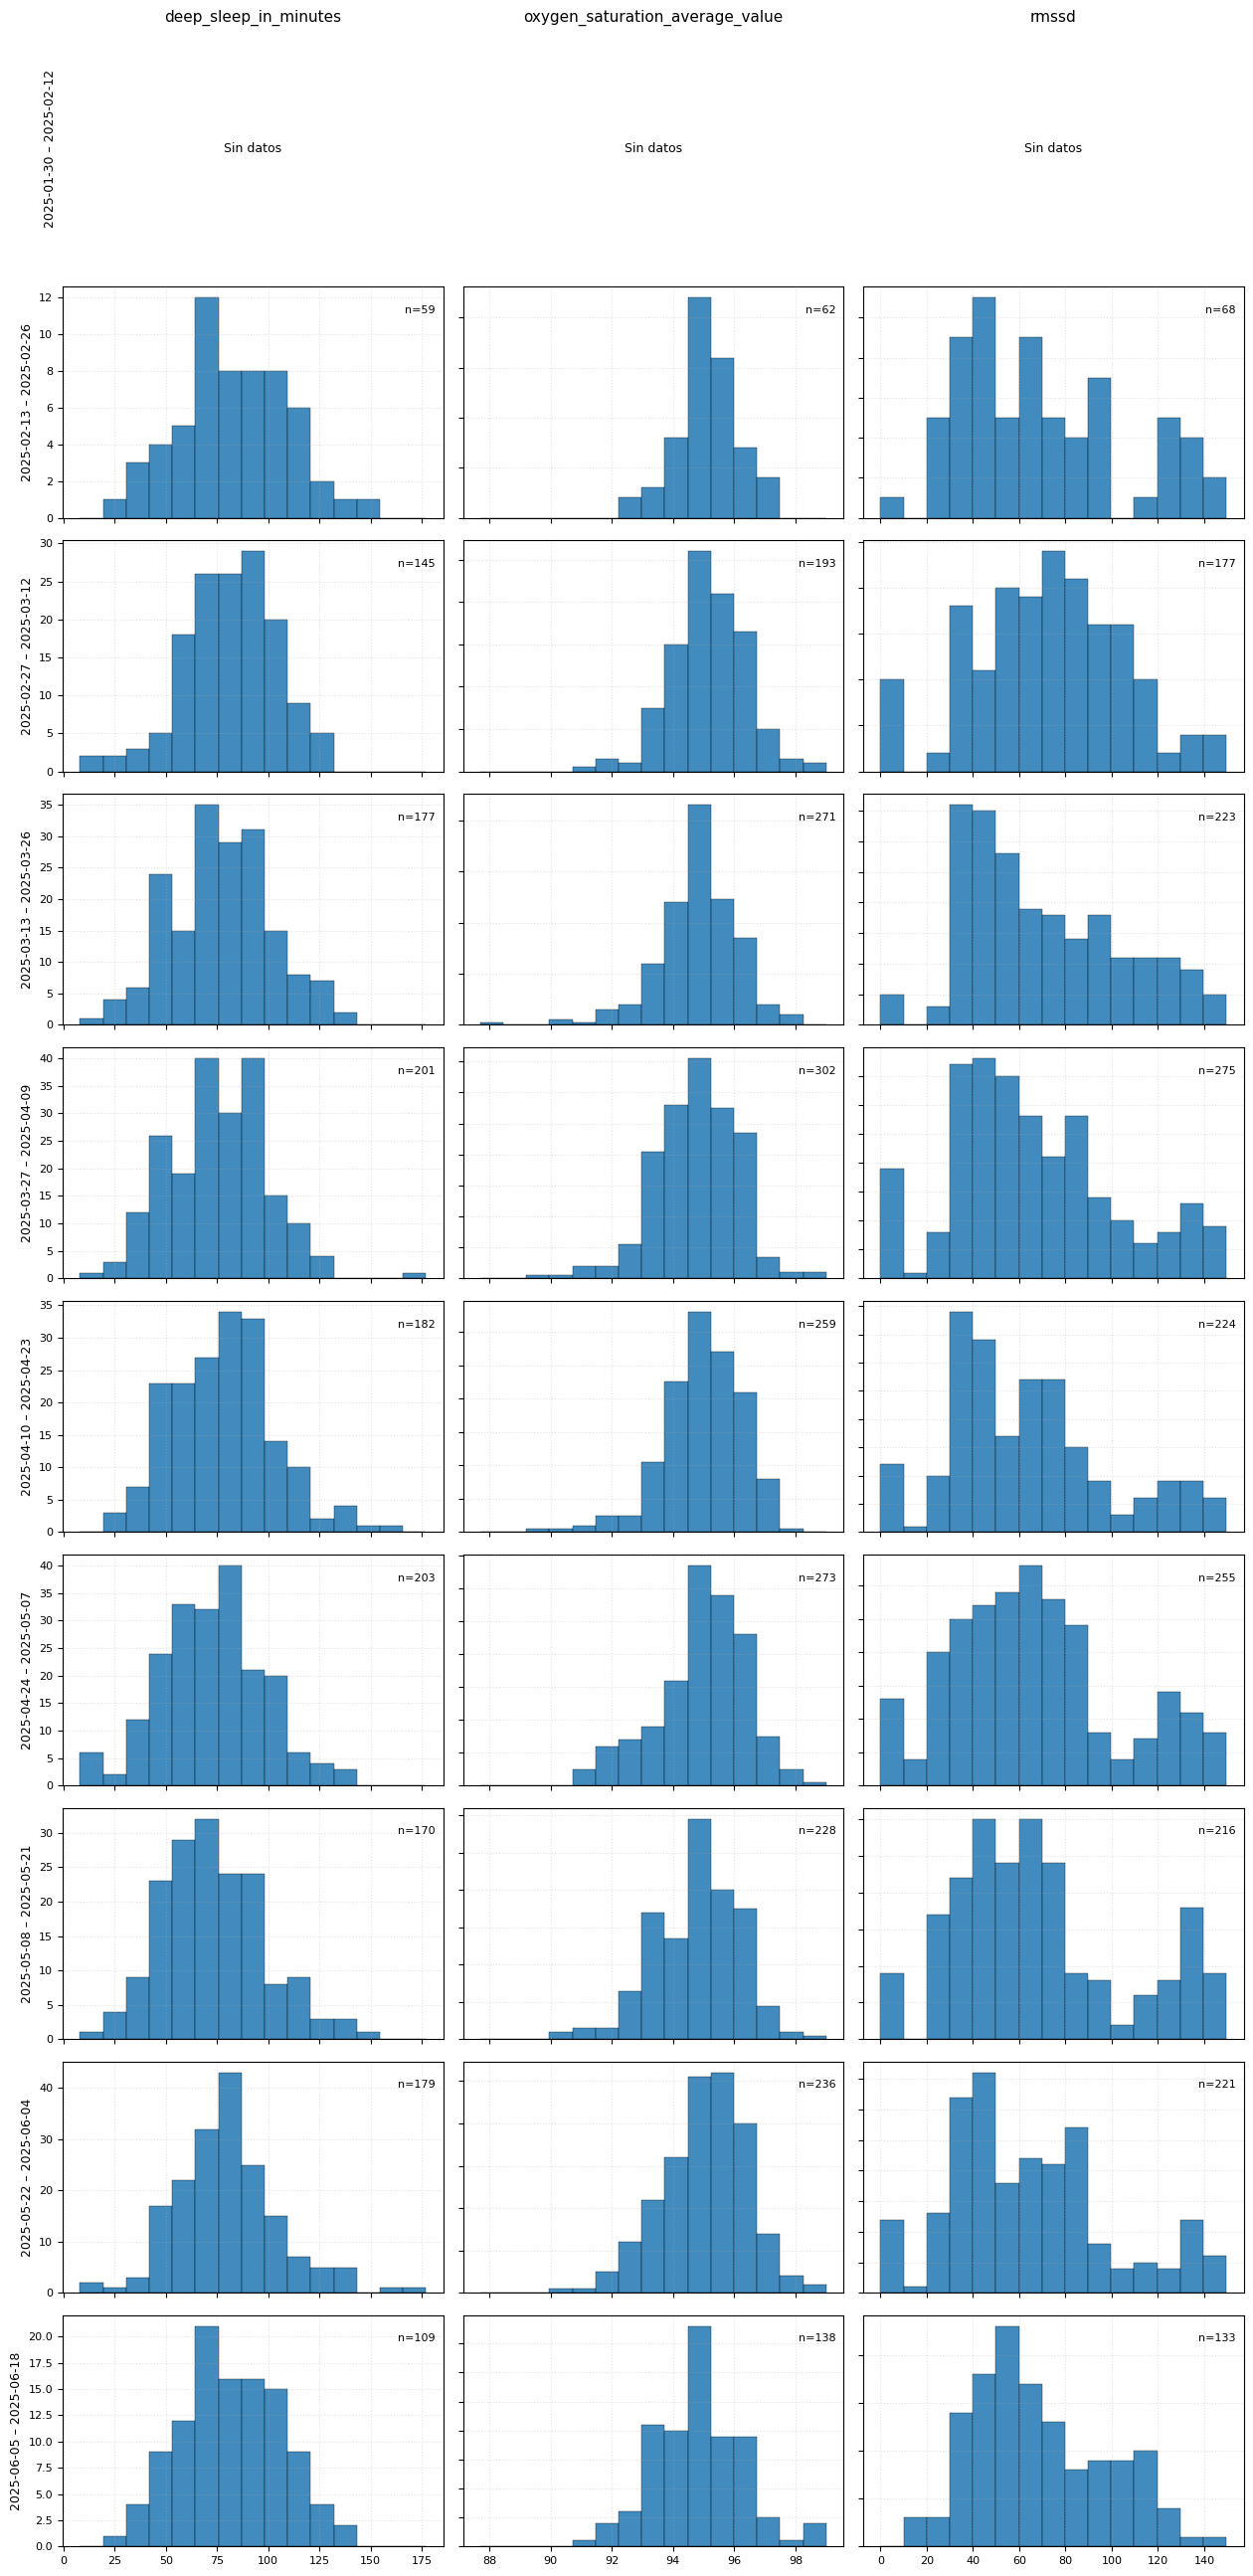

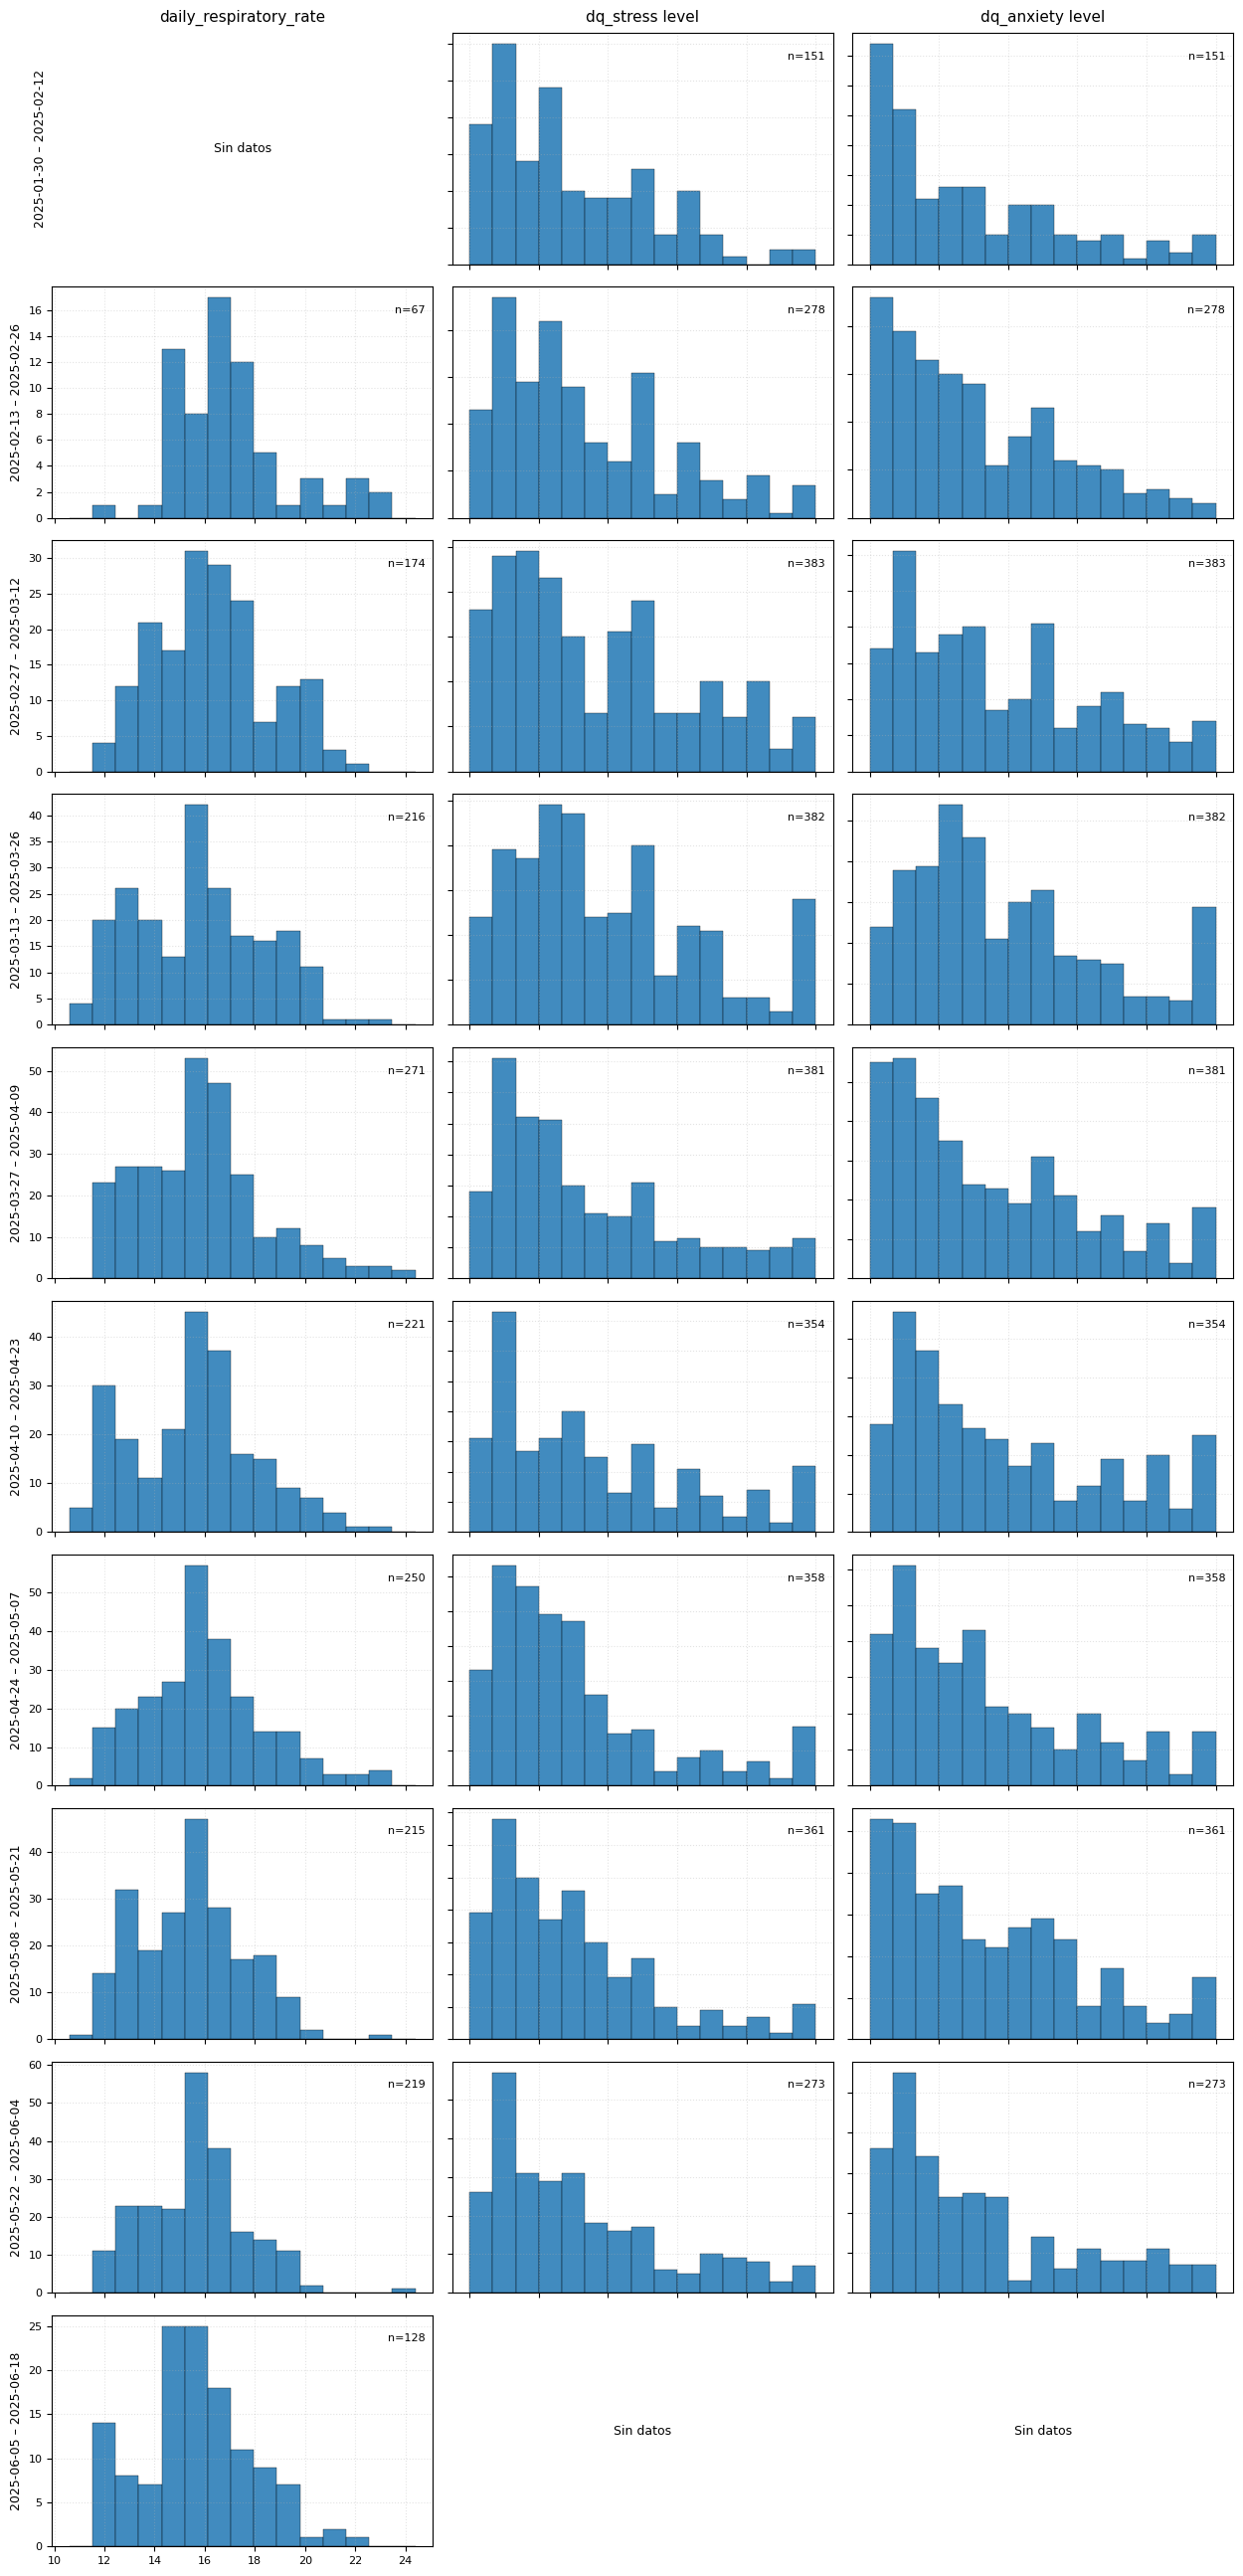

In [16]:
# === Histogramas por quincena: una columna por variable, una fila por quincena ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Configuración ---
cols = numeric_cols[:]                      
cols_por_pagina = 3                         
bins_por_var = 15                           
date_col = "date" if "date" in df.columns else None
assert date_col is not None, "No encuentro la columna de fechas 'date' en df."
df = df.copy()
df[date_col] = pd.to_datetime(df[date_col])

# --- Rango de fechas en quincenas (14 días) ---
date_min = df[date_col].min().normalize()
date_max = df[date_col].max().normalize()
# puntos cada 14 días, inclusivo en el extremo final
bordes = pd.date_range(start=date_min, end=date_max + pd.Timedelta(days=1), freq="14D")
date_ranges = list(zip(bordes[:-1], bordes[1:]))

print(f"Rangos: {date_ranges[0][0].date()} → {date_ranges[-1][1].date()}  "
      f"({len(date_ranges)} quincenas)")

# --- Paginación por columnas (variables) ---
for start_idx in range(0, len(cols), cols_por_pagina):
    subset = cols[start_idx:start_idx + cols_por_pagina]
    n_cols = len(subset)
    n_rows = len(date_ranges)

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(4.2*n_cols, 2.6*n_rows), sharex=False, sharey=False
    )
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    for j, col in enumerate(subset):
        serie_total = df[col].dropna()
        if serie_total.empty:
            for i in range(n_rows):
                axes[i, j].axis("off")
            continue
        bin_edges = np.histogram_bin_edges(serie_total, bins=bins_por_var)

        axes[0, j].set_title(col, fontsize=11, pad=8)

        for i, (ini, fin) in enumerate(date_ranges):
            ax = axes[i, j]
            s = df[(df[date_col] >= ini) & (df[date_col] < fin)][col].dropna()

            if s.empty:
                ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", fontsize=9)
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
            else:
                ax.hist(s, bins=bin_edges, alpha=0.85, edgecolor="black", linewidth=0.3)
                # n
                ax.text(0.98, 0.92, f"n={len(s)}", ha="right", va="top",
                        transform=ax.transAxes, fontsize=8)

            if j == 0:
                fin_inclusivo = (fin - pd.Timedelta(days=1)).date()
                ax.set_ylabel(f"{ini.date()} – {fin_inclusivo}", fontsize=9)
            else:
                ax.set_yticklabels([])

            ax.grid(True, linestyle=":", alpha=0.35)
            ax.tick_params(axis='both', labelsize=8)

        for i in range(n_rows - 1):
            axes[i, j].set_xticklabels([])

    plt.tight_layout()
    plt.show()


every 2 weeks

## 5. Check for duplicates

In [17]:
total_dups = df.duplicated().sum()
print("Exact duplicate rows:", total_dups)

# If you have a natural key like (user_id, date), check that too:
if {"user_id","date"}.issubset(df.columns):
    key_dups = df.duplicated(subset=["user_id","date"]).sum()
    print("Duplicate (user_id, date) rows:", key_dups)


Exact duplicate rows: 0
Duplicate (user_id, date) rows: 0


## 6. Other visualizations

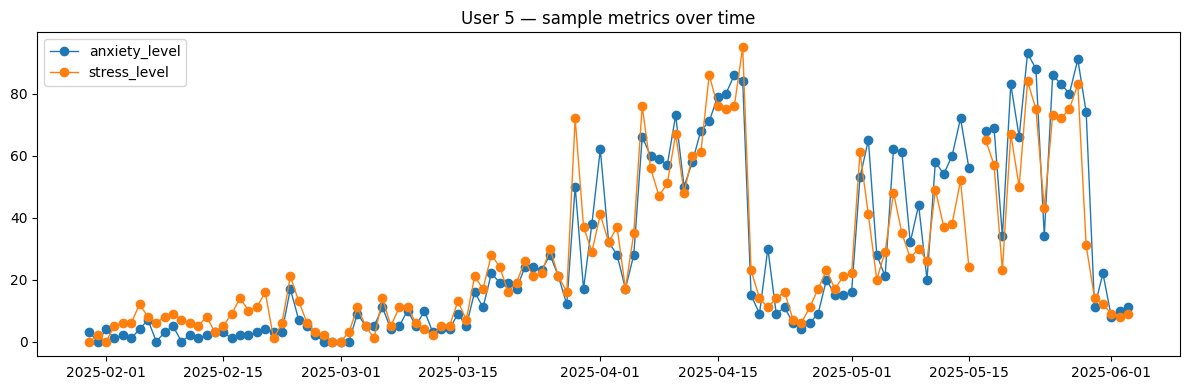

In [28]:
# Pick a user with many records and plot a few metrics over time
if {"user_id","date"}.issubset(df.columns) and len(numeric_cols) > 0:
    top_user = (df.groupby("user_id")["date"].count().sort_values(ascending=False).index[0]
                if df["date"].notna().any() else df["user_id"].value_counts().index[0])

    user_df = df[df["user_id"] == top_user].sort_values("date")

    plot_cols = ['dq_anxiety level', 'dq_stress level']

    if not user_df.empty:
        plt.figure(figsize=(12,4))

        for c in plot_cols:
            if c in user_df.columns:
                clean_label = c.replace("dq_", "").replace(" ", "_")
                plt.plot(
                    user_df["date"],
                    user_df[c],
                    marker="o",
                    linewidth=1,
                    label=clean_label
                )

        plt.title(f"User {top_user} — sample metrics over time")
        plt.legend()
        plt.tight_layout()
        plt.show()

antes vs despues de la platica
PENDIENTE

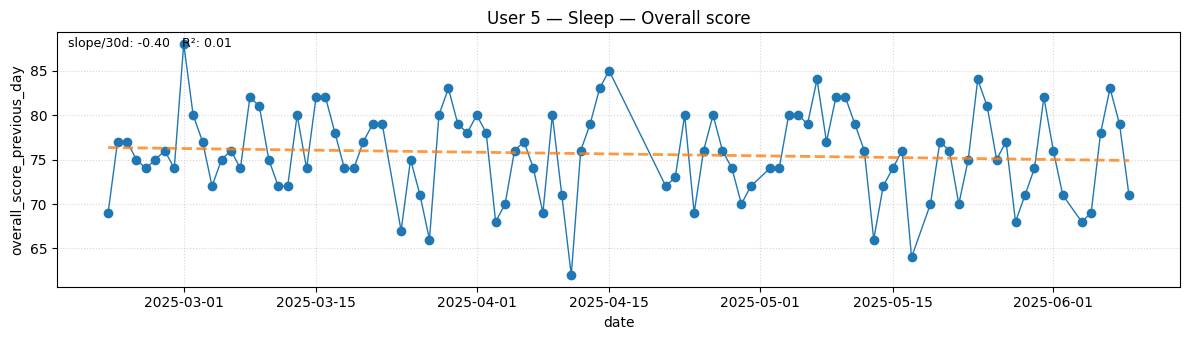

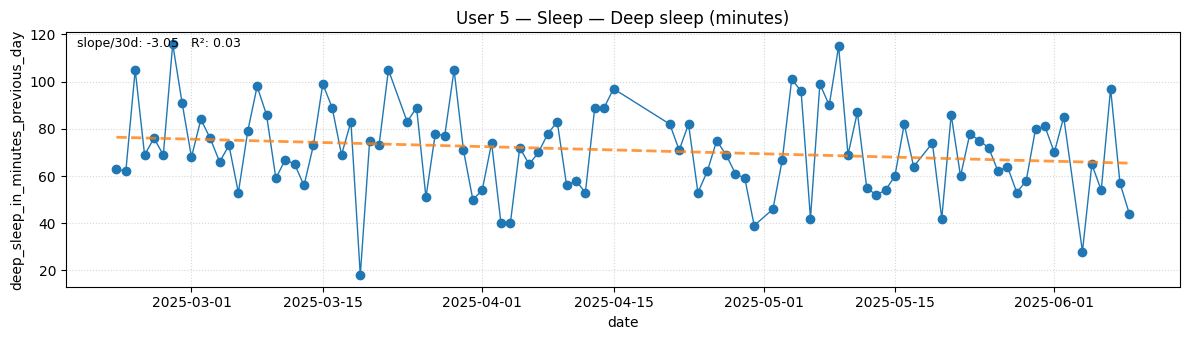

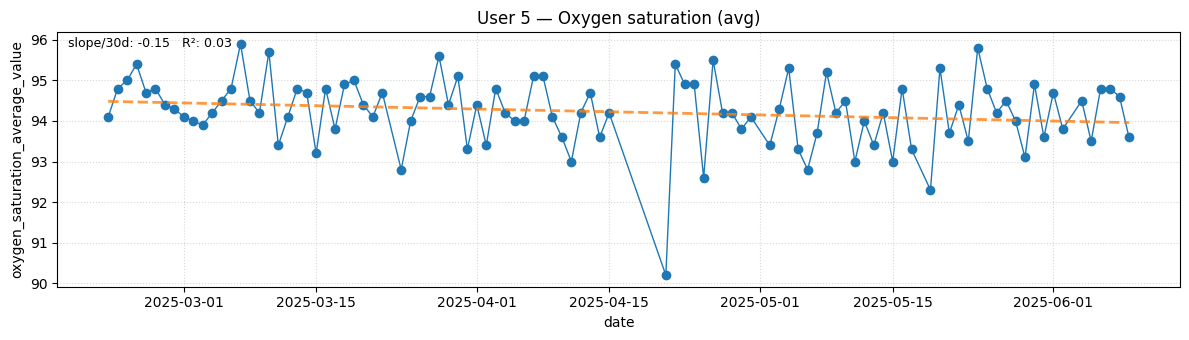

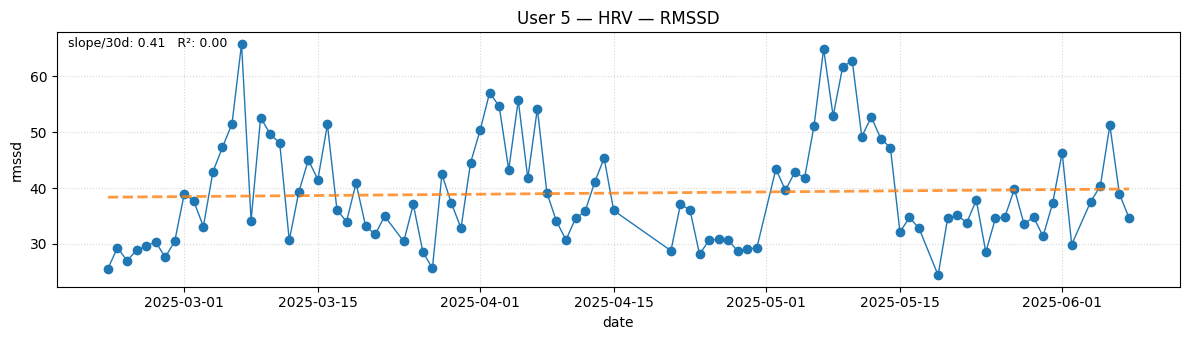

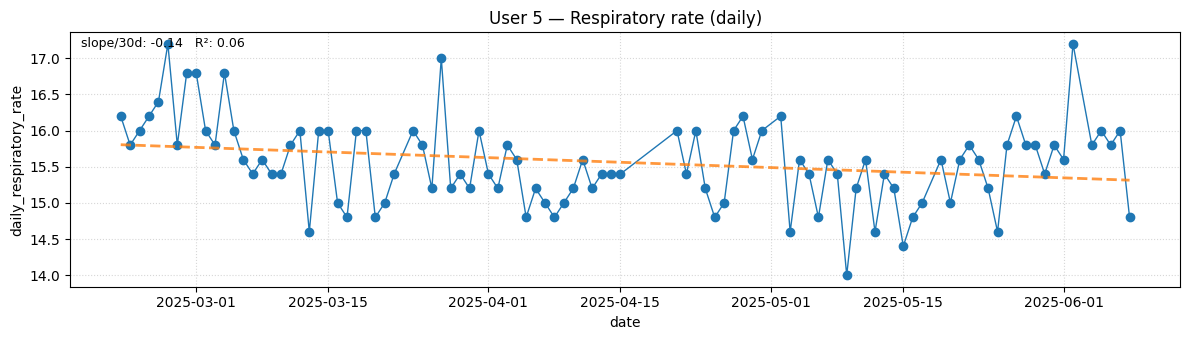

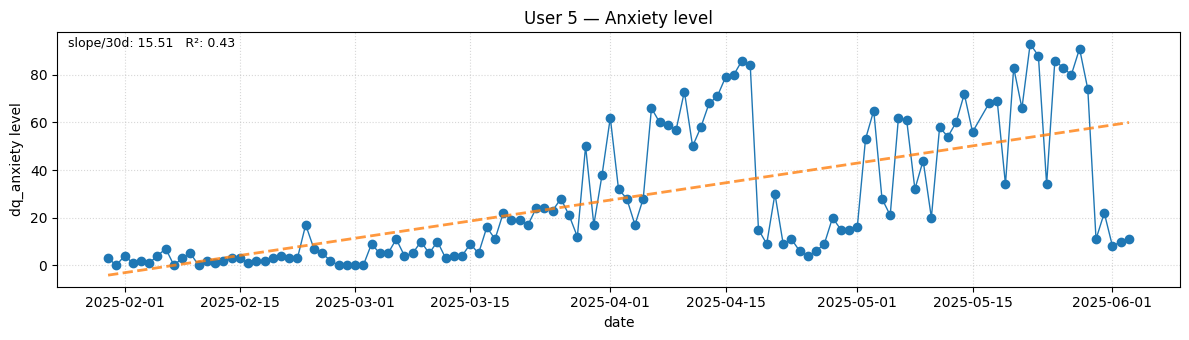

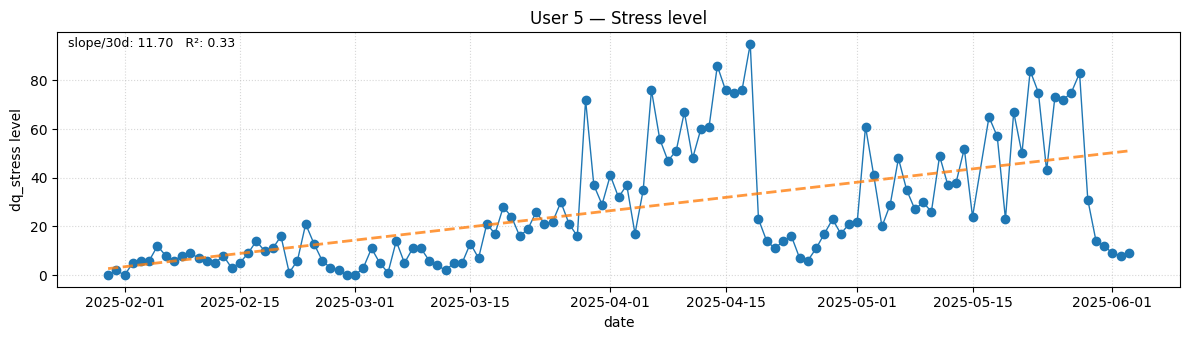

In [19]:
# Parse basics
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["user_id"] = df["user_id"].astype(str)
df = df.dropna(subset=["date"])

# Pick user with most records
top_user = df.groupby("user_id")["date"].count().idxmax()
user_df = df[df["user_id"] == top_user].copy().sort_values("date")

# Helper to pick the first column name that exists
def pick(*names):
    for n in names:
        if n in user_df.columns:
            return n
    return None

# Map titles -> actual columns (auto-detect anxiety/stress si cambia el nombre)
metric_map = {
    "Sleep — Overall score":              pick("overall_score_previous_day", "overall_score"),
    "Sleep — Deep sleep (minutes)":       pick("deep_sleep_in_minutes_previous_day", "deep_sleep_in_minutes"),
    "Oxygen saturation (avg)":            pick("oxygen_saturation_average_value", "oxygen_saturation"),
    "HRV — RMSSD":                        pick("rmssd", "mssd", "rMSSD"),
    "Respiratory rate (daily)":           pick("daily_respiratory_rate", "respiratory_rate"),
    "Anxiety level":                      pick("dq_anxiety level", "anxiety_level"),
    "Stress level":                       pick("dq_stress level", "stress_level"),
}

# --- util: añadir línea de regresión a un eje ---
def add_linear_regression(ax, x_dates: pd.Series, y: pd.Series, show_annotation=True):
    """
    Dibuja la recta de regresión y devuelve (slope_per_day, intercept, r2).
    x_dates: serie de datetime (ordenada)
    y: valores numéricos
    """
    # x como días desde el inicio (escala estable)
    x0 = x_dates.min()
    x = (x_dates - x0).dt.days.astype(float).to_numpy()
    yv = y.to_numpy()

    # proteger por si no hay varianza
    if len(x) < 2 or np.isclose(np.var(x), 0) or np.isclose(np.var(yv), 0):
        return None

    b, a = np.polyfit(x, yv, 1)   # y = a + b*x
    y_hat = a + b * x

    # dibujar recta sobre todo el rango
    ax.plot(x_dates, y_hat, linestyle="--", linewidth=2, alpha=0.8)

    # R^2
    r = np.corrcoef(x, yv)[0, 1]
    r2 = float(r**2) if not np.isnan(r) else np.nan

    if show_annotation:
        slope_30d = b * 30.0
        txt = f"slope/30d: {slope_30d:.2f}   R²: {r2:.2f}"
        ax.text(0.01, 0.98, txt, transform=ax.transAxes, ha="left", va="top", fontsize=9)

    return b, a, r2

# 6) Plot each metric separately con línea de regresión
for title, col in metric_map.items():
    if col is None or col not in user_df.columns:
        continue

    daily = (user_df[["date", col]]
             .dropna()
             .groupby("date", as_index=False)[col].mean()
             .sort_values("date"))

    if daily.empty:
        continue

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(daily["date"], daily[col], marker="o", linewidth=1)
    add_linear_regression(ax, daily["date"], daily[col], show_annotation=True)

    ax.set_title(f"User {top_user} — {title}")
    ax.set_xlabel("date"); ax.set_ylabel(col)
    ax.grid(True, linestyle=":", alpha=0.5)
    fig.tight_layout()
    plt.show()



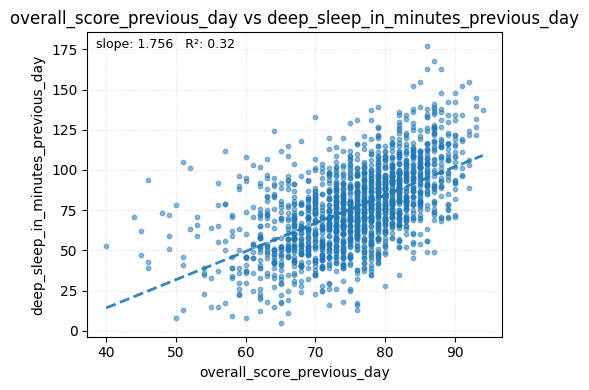

In [20]:
# Simple scatter sleep score vs deep sleep 
if len(numeric_cols) >= 2:
    x_col, y_col = numeric_cols[0], numeric_cols[1]

    tmp = df[[x_col, y_col]].dropna()
    x = tmp[x_col].to_numpy(dtype=float)
    y = tmp[y_col].to_numpy(dtype=float)

    plt.figure(figsize=(5, 4))
    plt.scatter(x, y, s=10, alpha=0.5)

    # Ajuste lineal y = a + b*x (si hay varianza suficiente)
    if len(x) >= 2 and np.var(x) > 0 and np.var(y) > 0:
        b, a = np.polyfit(x, y, 1)  # y = a + b*x
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = a + b * x_line
        plt.plot(x_line, y_line, linestyle="--", linewidth=2, alpha=0.9)

        # R^2
        r = np.corrcoef(x, y)[0, 1]
        r2 = float(r**2) if not np.isnan(r) else np.nan
        plt.text(0.02, 0.98, f"slope: {b:.3f}   R²: {r2:.2f}",
                 transform=plt.gca().transAxes, ha="left", va="top", fontsize=9)

    plt.xlabel(x_col); plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col}")
    plt.grid(True, linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()



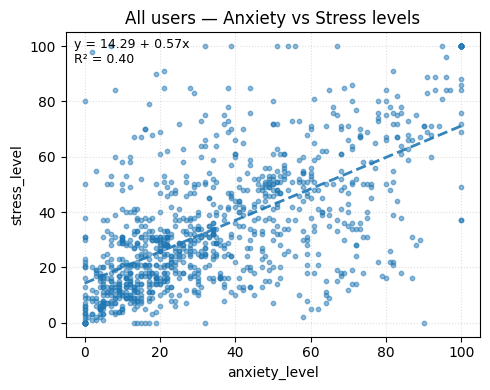

In [29]:
# Scatter anxiety vs sleep score
if {'dq_anxiety level', 'overall_score_previous_day'}.issubset(df_cleaned.columns):
    x = df_cleaned['dq_anxiety level']
    y = df_cleaned['dq_stress level']

    # limpiar NaN y convertir a float
    tmp = (pd.DataFrame({'x': x, 'y': y})
             .dropna())
    xv = tmp['x'].to_numpy(dtype=float)
    yv = tmp['y'].to_numpy(dtype=float)

    plt.figure(figsize=(5, 4))
    plt.scatter(xv, yv, s=10, alpha=0.5)

    # Ajuste lineal y = a + b*x
    if len(xv) >= 2 and np.var(xv) > 0 and np.var(yv) > 0:
        b, a = np.polyfit(xv, yv, 1)  # y = a + b*x
        x_line = np.linspace(xv.min(), xv.max(), 100)
        y_line = a + b * x_line
        plt.plot(x_line, y_line, linestyle="--", linewidth=2, alpha=0.9)

        # R^2 y ecuación
        r = np.corrcoef(xv, yv)[0, 1]
        r2 = float(r**2) if not np.isnan(r) else np.nan
        plt.text(0.02, 0.98, f"y = {a:.2f} + {b:.2f}x\nR² = {r2:.2f}",
                 transform=plt.gca().transAxes, ha="left", va="top", fontsize=9)

    plt.xlabel('anxiety_level')
    plt.ylabel('stress_level')
    plt.title("All users — Anxiety vs Stress levels")
    plt.grid(True, linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()


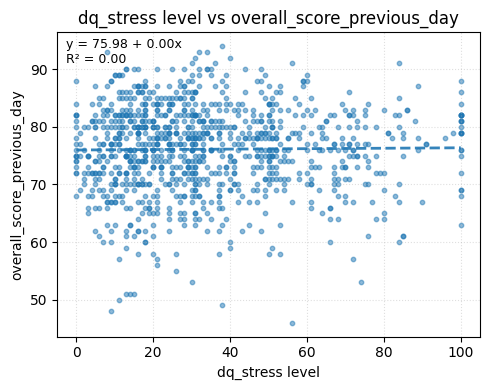

In [22]:
# Scatter stress vs sleep score
if {'dq_stress level', 'overall_score_previous_day'}.issubset(df_cleaned.columns):
    x = df_cleaned['dq_stress level']
    y = df_cleaned['overall_score_previous_day']

    tmp = pd.DataFrame({'x': x, 'y': y}).dropna()
    xv = tmp['x'].to_numpy(dtype=float)
    yv = tmp['y'].to_numpy(dtype=float)

    plt.figure(figsize=(5, 4))
    plt.scatter(xv, yv, s=10, alpha=0.5)

    # Ajuste lineal y = a + b*x
    if len(xv) >= 2 and np.var(xv) > 0 and np.var(yv) > 0:
        b, a = np.polyfit(xv, yv, 1)  # y = a + b*x
        xx = np.linspace(xv.min(), xv.max(), 100)
        yy = a + b * xx
        plt.plot(xx, yy, linestyle="--", linewidth=2, alpha=0.9)

        r = np.corrcoef(xv, yv)[0, 1]
        r2 = float(r**2) if not np.isnan(r) else np.nan
        plt.text(0.02, 0.98, f"y = {a:.2f} + {b:.2f}x\nR² = {r2:.2f}",
                 transform=plt.gca().transAxes, ha="left", va="top", fontsize=9)

    plt.xlabel('dq_stress level')
    plt.ylabel('overall_score_previous_day')
    plt.title("dq_stress level vs overall_score_previous_day")
    plt.grid(True, linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()


agregar linea de regresion

stress vs overall score

## 7. Correlation Plots

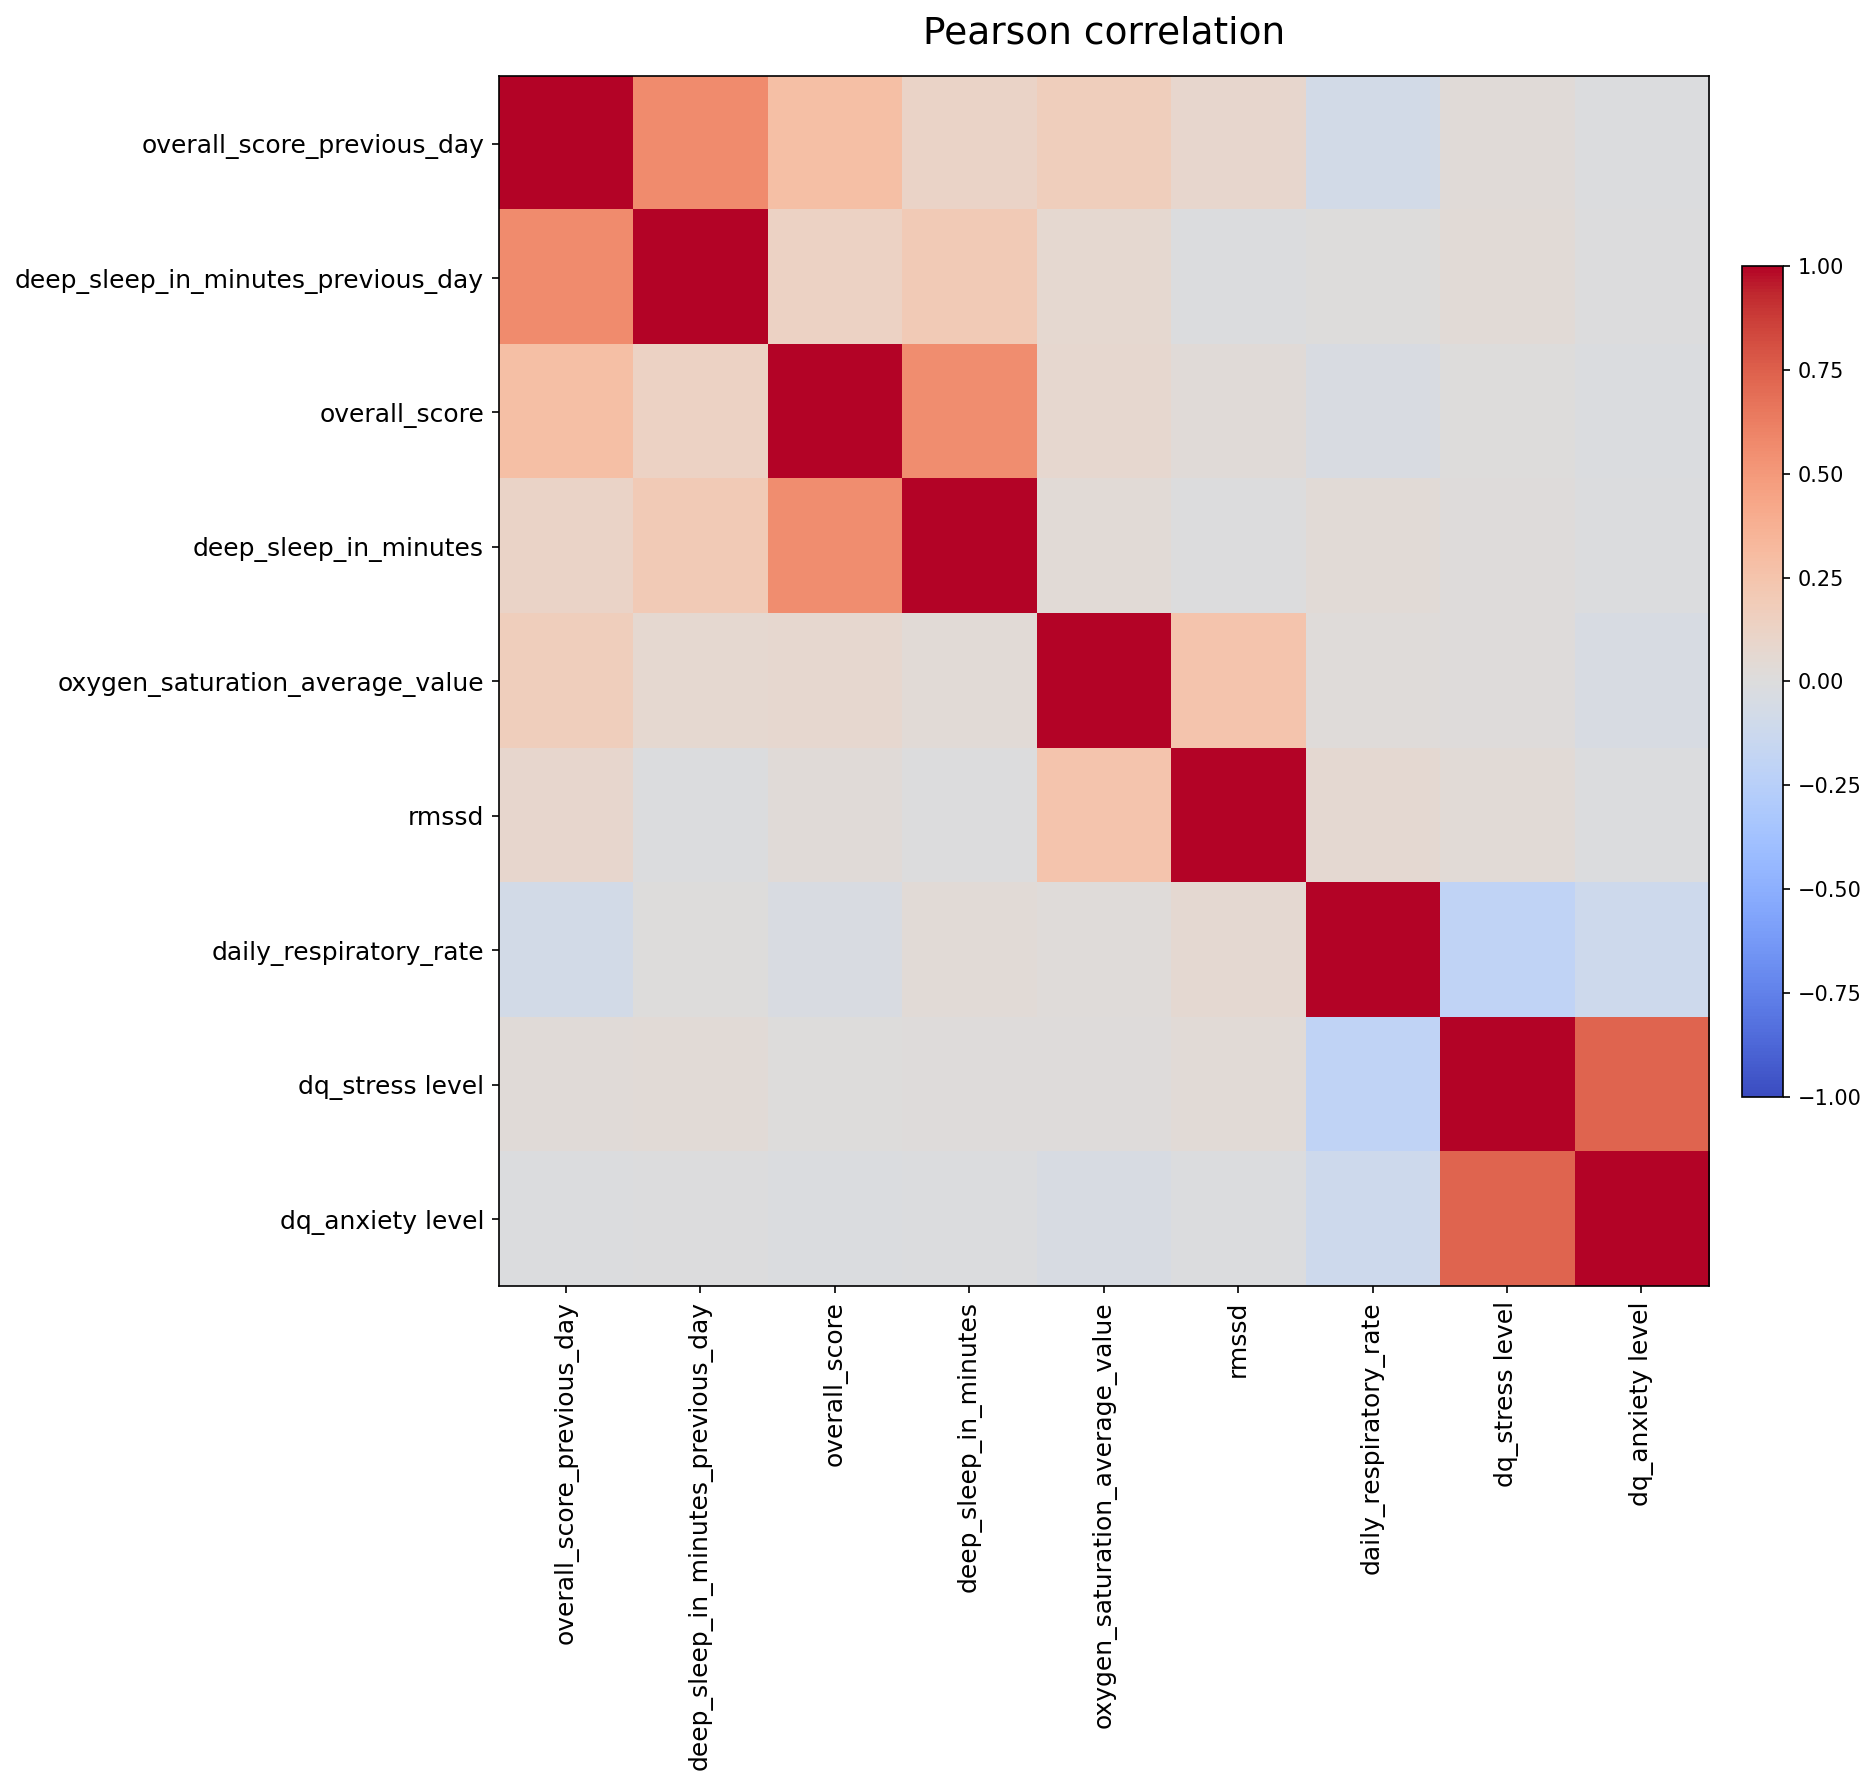

In [23]:
num = df[numeric_cols].copy()
corr = num.corr(method="pearson")

n = len(corr.columns)
scale = 0.8  # bump this up/down if you want even bigger/smaller

fig_w = max(14, scale * n)
fig_h = max(12, scale * n)

plt.figure(figsize=(fig_w, fig_h), dpi=150)
im = plt.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
cbar = plt.colorbar(im, fraction=0.025, pad=0.02)

plt.xticks(range(n), corr.columns, rotation=90, fontsize=12)
plt.yticks(range(n), corr.index, fontsize=12)
plt.title("Pearson correlation", fontsize=18, pad=16)

plt.tight_layout()
plt.show()


## 8. Weekdays Plots

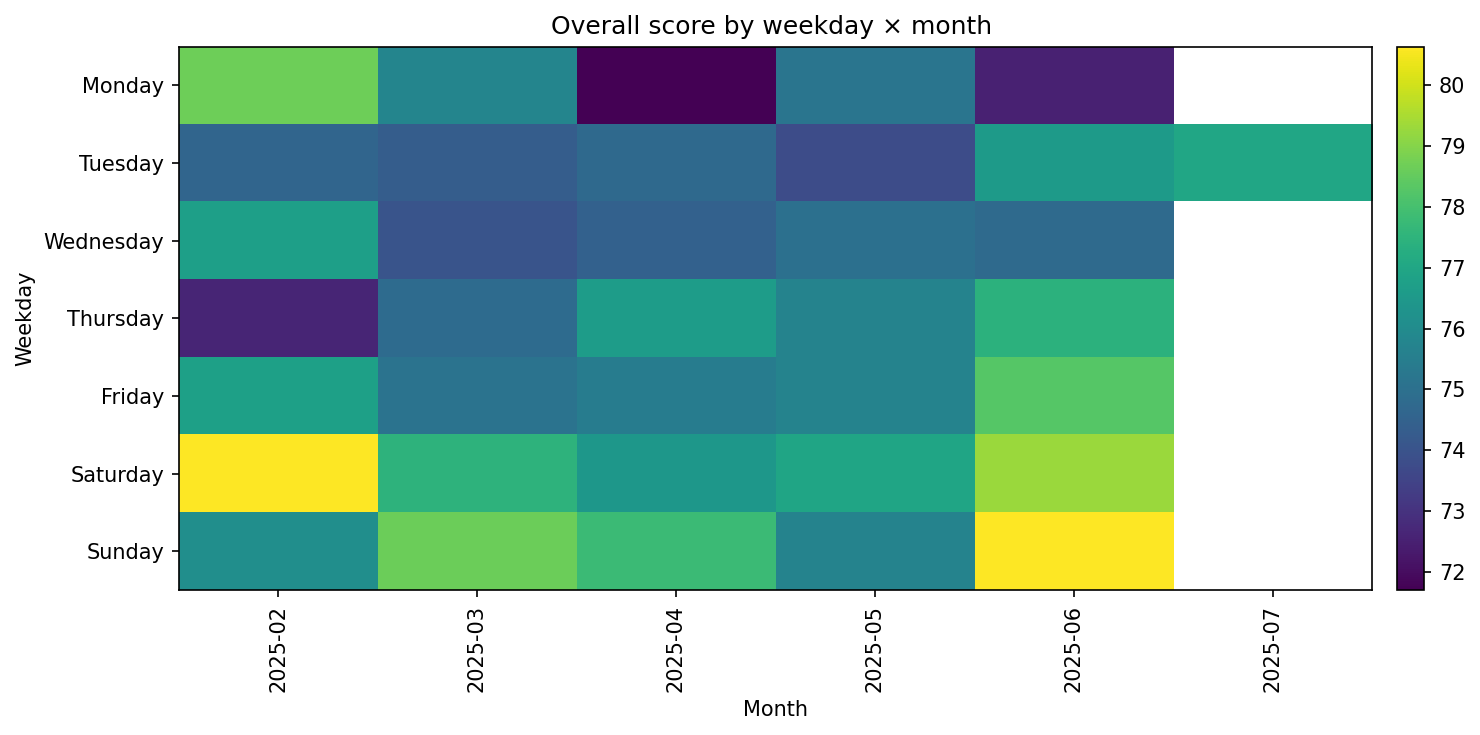

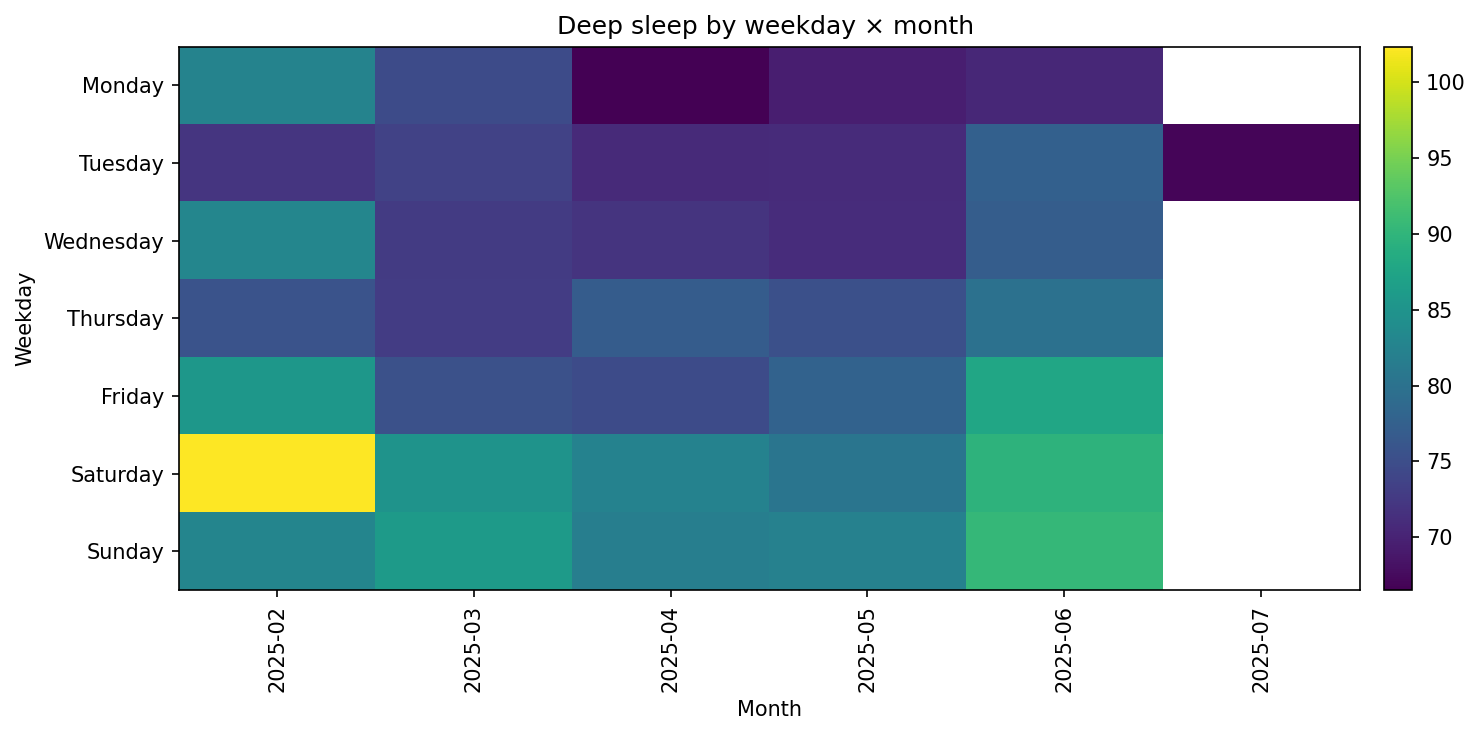

In [24]:
df = df.dropna(subset=["date"])

# pick the available column names
overall_col = "overall_score_previous_day"
deep_col    = "deep_sleep_in_minutes_previous_day"

# helper to build a weekday x month heatmap pivot for a given metric column
def make_weekday_month_pivot(metric_col):
    tmp = df[["date", metric_col]].dropna().copy()
    tmp["weekday"] = tmp["date"].dt.day_name()
    tmp["month"] = tmp["date"].dt.to_period("M").astype(str)  # e.g., '2025-05'
    pivot = tmp.pivot_table(index="weekday", columns="month", values=metric_col, aggfunc="mean")
    # reorder rows to Mon..Sun
    order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    pivot = pivot.reindex(order)
    return pivot

# build pivots
pivot_overall = make_weekday_month_pivot(overall_col)
pivot_deep    = make_weekday_month_pivot(deep_col)

# plotting helper
def plot_heatmap(pivot, title):
    if pivot.empty:
        print(f"[INFO] No data for {title}")
        return
    n_cols = pivot.shape[1]
    fig_w = max(10, 0.8 * n_cols)  # widen if many months
    fig, ax = plt.subplots(figsize=(fig_w, 5), dpi=150)
    im = ax.imshow(pivot.values, aspect="auto")  # use default colormap
    cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=90)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Weekday")
    plt.tight_layout()
    plt.show()

# draw heatmaps
plot_heatmap(pivot_overall, f"Overall score by weekday × month ")
plot_heatmap(pivot_deep,    f"Deep sleep by weekday × month ")


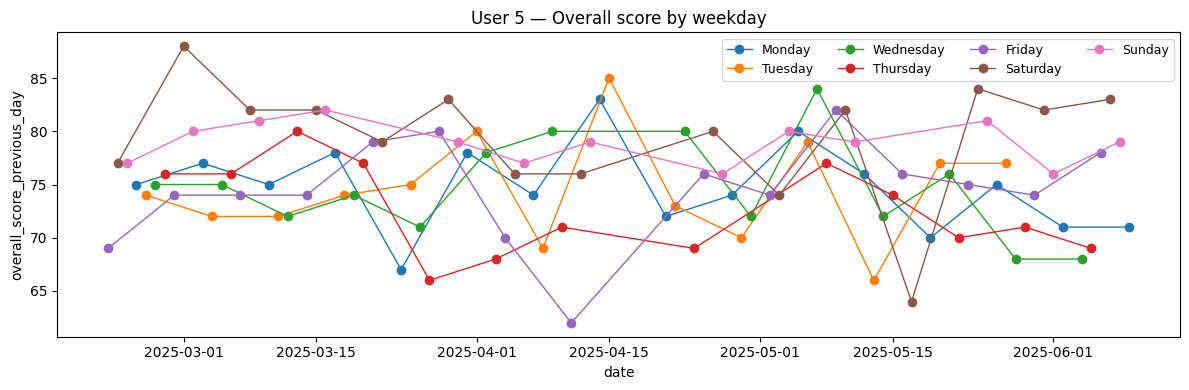

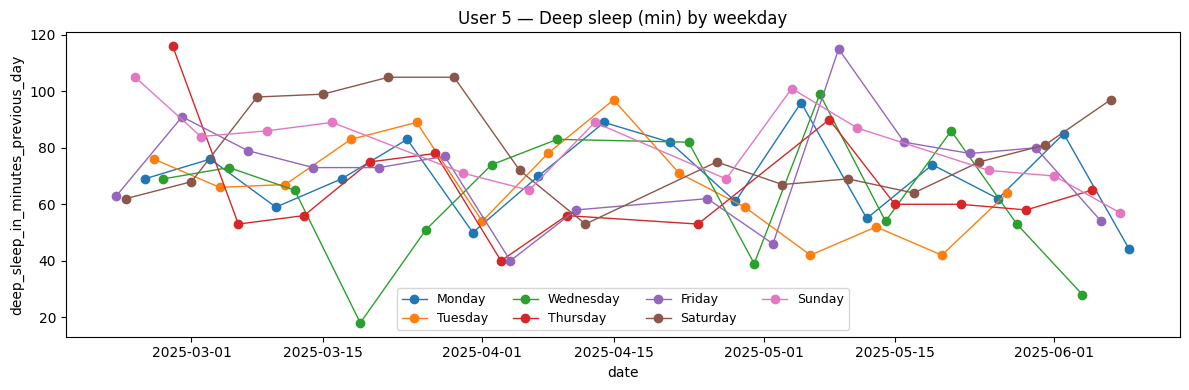

In [25]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["user_id"] = df["user_id"].astype(str)
df = df.dropna(subset=["date"])

top_user = df.groupby("user_id")["date"].count().idxmax()
user_df = df[df["user_id"] == top_user].copy().sort_values("date")

# Use whichever column names you have
overall_col = "overall_score_previous_day" 
deep_col    = "deep_sleep_in_minutes_previous_day"

weekdays = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# ---- Overall score: one line per weekday ----
tmp = user_df[["date", overall_col]].dropna().copy()
tmp["weekday"] = tmp["date"].dt.day_name()

plt.figure(figsize=(12, 4))
for wd in weekdays:
    s = tmp[tmp["weekday"] == wd].sort_values("date")
    if not s.empty:
        plt.plot(s["date"], s[overall_col], marker="o", linewidth=1, label=wd)
plt.title(f"User {top_user} — Overall score by weekday")
plt.xlabel("date"); plt.ylabel(overall_col)
plt.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

# ---- Deep sleep (minutes): one line per weekday ----
tmp = user_df[["date", deep_col]].dropna().copy()
tmp["weekday"] = tmp["date"].dt.day_name()

plt.figure(figsize=(12, 4))
for wd in weekdays:
    s = tmp[tmp["weekday"] == wd].sort_values("date")
    if not s.empty:
        plt.plot(s["date"], s[deep_col], marker="o", linewidth=1, label=wd)
plt.title(f"User {top_user} — Deep sleep (min) by weekday")
plt.xlabel("date"); plt.ylabel(deep_col)
plt.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()


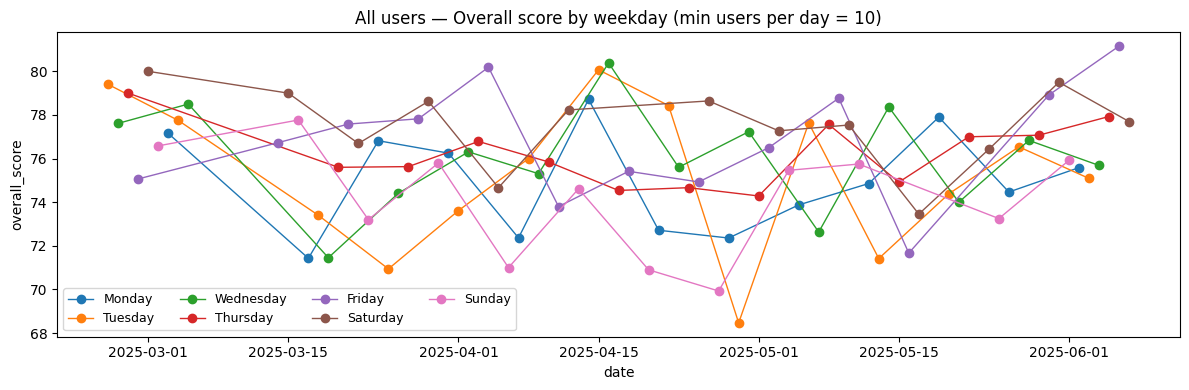

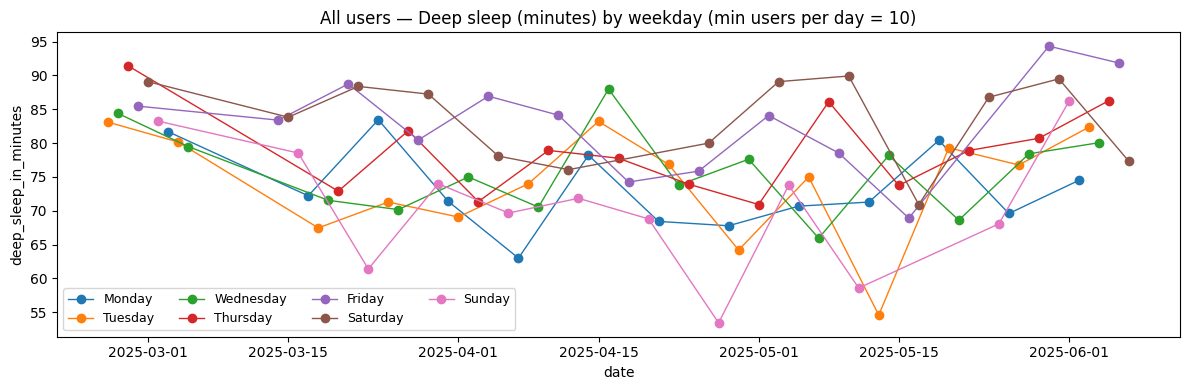

In [26]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["user_id"] = df["user_id"].astype(str)
df = df.dropna(subset=["date"])


overall_col = "overall_score"
deep_col    = "deep_sleep_in_minutes"

# Per-date mean across users (NaNs ignored) + coverage (user count per day for each metric)
agg = (df.groupby("date")[[overall_col, deep_col]]
         .agg(["mean", "count"])
         .reset_index())
agg.columns = ["date", "overall_mean", "overall_n", "deep_mean", "deep_n"]
agg["weekday"] = agg["date"].dt.day_name()

# Keep only reasonably-covered days (avoid bias from very few users)
min_users = 10  # <-- adjust for your dataset size
weekdays = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# Plot Overall score
plt.figure(figsize=(12, 4))
for wd in weekdays:
    s = agg[(agg["weekday"] == wd) & (agg["overall_n"] >= min_users)][["date", "overall_mean"]]
    if not s.empty:
        s = s.sort_values("date")
        plt.plot(s["date"], s["overall_mean"], marker="o", linewidth=1, label=wd)
plt.title(f"All users — Overall score by weekday (min users per day = {min_users})")
plt.xlabel("date"); plt.ylabel(overall_col)
plt.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

# Plot Deep sleep in minutes
plt.figure(figsize=(12, 4))
for wd in weekdays:
    s = agg[(agg["weekday"] == wd) & (agg["deep_n"] >= min_users)][["date", "deep_mean"]]
    if not s.empty:
        s = s.sort_values("date")
        plt.plot(s["date"], s["deep_mean"], marker="o", linewidth=1, label=wd)
plt.title(f"All users — Deep sleep (minutes) by weekday (min users per day = {min_users})")
plt.xlabel("date"); plt.ylabel(deep_col)
plt.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()


In [27]:
df = df.dropna(subset=["date"])

# pick column names that exist in your data
overall_col = "overall_score" if "overall_score" in df.columns else "overall_score_previous_day"
deep_col    = "deep_sleep_in_minutes" if "deep_sleep_in_minutes" in df.columns else "deep_sleep_in_minutes_previous_day"

# group by weekday name and compute means across all users/dates
weekday = df["date"].dt.day_name()
gb = df.groupby(weekday)

weekday_mean = pd.DataFrame({
    "overall_score_mean": gb[overall_col].mean(),
    "deep_sleep_minutes_mean": gb[deep_col].mean(),
})

# order rows Monday..Sunday and round for readability
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_mean = weekday_mean.reindex(order).round(2)

weekday_mean


,overall_score_mean,deep_sleep_minutes_mean
date,,
Monday,75.19,73.05
Tuesday,75.27,74.38
Wednesday,76.13,75.58
Thursday,76.33,79.96
Friday,77.06,83.83
Saturday,78.16,85.03
Sunday,74.11,70.37
